# Introduction

This will cover Regularized Logistic Regression (1st method)

Comparison of data with the following paper [[3]](../README.md#ref-3)

## 1 Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import warnings
from sklearn.exceptions import ConvergenceWarning

# Suppress convergence warnings (expected at low iteration counts)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [2]:
import sys
import importlib

# --- FIX: AUTORELOAD FOR JUPYTER ---
# These lines ensure that when you save changes to logistic_regression.py, 
# the notebook will automatically reload the new code.
%load_ext autoreload
%autoreload 2
# -----------------------------------

# Now importing DH_OBJ from the logistic_regression package
try:
    # 1. Check if the module is already loaded (cached)
    if 'utils' in sys.modules:
        print("Module 'utils' found in cache. Forcing reload...")
        importlib.reload(sys.modules['utils'])
    
    # 2. Perform the import (this will use the reloaded or new version)
    import utils as ut
except ImportError as e:
    print(f"\n[ERROR] Import failed. Ensure your 'logistic_regression' folder and 'logistic_regression.py' are correctly structured.")
    print(f"Details: {e}")
    sys.exit(1)

In [3]:
# Set styles and seeds for reproducibility
plt.style.use('seaborn-v0_8')
sns.set_palette(sns.color_palette())
np.random.seed(42)

## 2 Loading and data visualization

In [4]:
# Load data
df = pd.read_excel("../data/Dry_Bean_Dataset.xlsx")

# Separate features and target (using all data)
X_full = df.drop(columns=['Class']).values # Use all 16 features
y_full = df['Class'].values # Use all 7 classes

# Encode the 7 class labels to integers (0 to 6)
label_encoder_full = LabelEncoder()
y_encoded_full = label_encoder_full.fit_transform(y_full)
num_classes = len(label_encoder_full.classes_)
target_names = label_encoder_full.classes_
input_shape = X_full.shape[1] # 16 features

print(f"Full dataset shape: {X_full.shape}")
print(f"Number of classes: {num_classes}")

Full dataset shape: (13611, 16)
Number of classes: 7


## 2.1 Splitting data set

Split the data in test and training data. It is advices reserving 20 - 40% of data set for testing. In this case, 33% of data is used for testing.

Then split test data in cross-validation and test in half. This way will be able to cross-validate the model and tune it before feeding test data which is done only once. Follow the following division precentage:
 
 * train - 67%
 * cross-validation - 16.5%
 * test - 16.5%

In [5]:
# Split the full dataset (67% train, 16.5% CV, 16.5% test)
# This uses the same split ratios as the Logistic Regression notebooks
X_train_full, X_, y_train_full, y_ = train_test_split(
    X_full, y_encoded_full, test_size=0.33, random_state=42, stratify=y_encoded_full
)

X_cv_full, X_test_full, y_cv_full, y_test_full = train_test_split(
    X_, y_, test_size=0.5, random_state=42, stratify=y_
)

# Scale all 16 features
scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train_full)
X_cv_scaled = scaler_full.transform(X_cv_full)
X_test_scaled = scaler_full.transform(X_test_full)

# desired order
labels_desired_order = ['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']

print(f"Train shapes: X={X_train_scaled.shape}, y={y_train_full.shape}")
print(f"CV shapes: X={X_cv_scaled.shape}, y={y_cv_full.shape}")
print(f"Test shapes: X={X_test_scaled.shape}, y={y_test_full.shape}")

Train shapes: X=(9119, 16), y=(9119,)
CV shapes: X=(2246, 16), y=(2246,)
Test shapes: X=(2246, 16), y=(2246,)


## 2.2 Visualization

Visual check of the class distirbution with bar chart

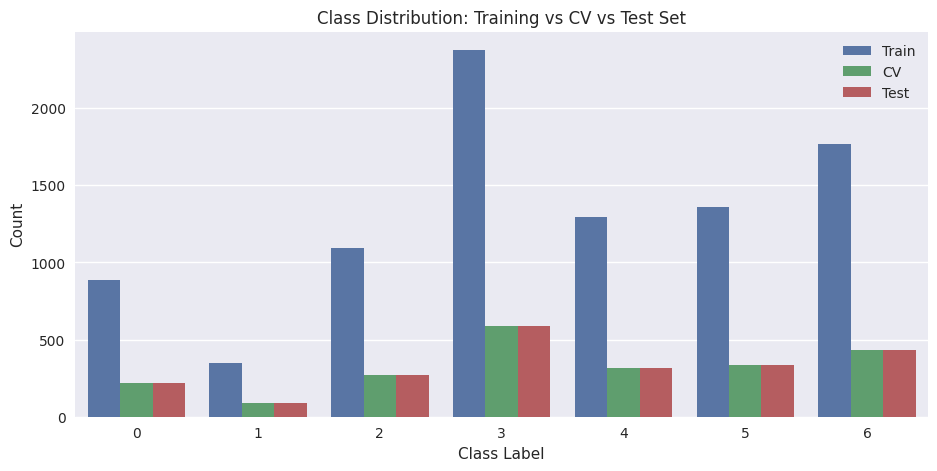

In [6]:
# Convert y_train and y_test to DataFrames for easier plotting with Seaborn
train_df = pd.DataFrame({'Label': y_train_full, 'Set': 'Train'})
test_cv = pd.DataFrame({'Label': y_cv_full, 'Set': 'CV'})
test_df = pd.DataFrame({'Label': y_test_full, 'Set': 'Test'})
combined_df = pd.concat([train_df, test_cv, test_df])

plt.figure(figsize=(11, 5))
sns.countplot(data=combined_df, x='Label', hue='Set')
plt.title('Class Distribution: Training vs CV vs Test Set')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.legend()
plt.show()

Visual check with PCA scatter Plot. All 16 features are squashed in 2 dimensions using PCA (Principal Component Analysis). This lets see if the training and test data occupy the same "space".

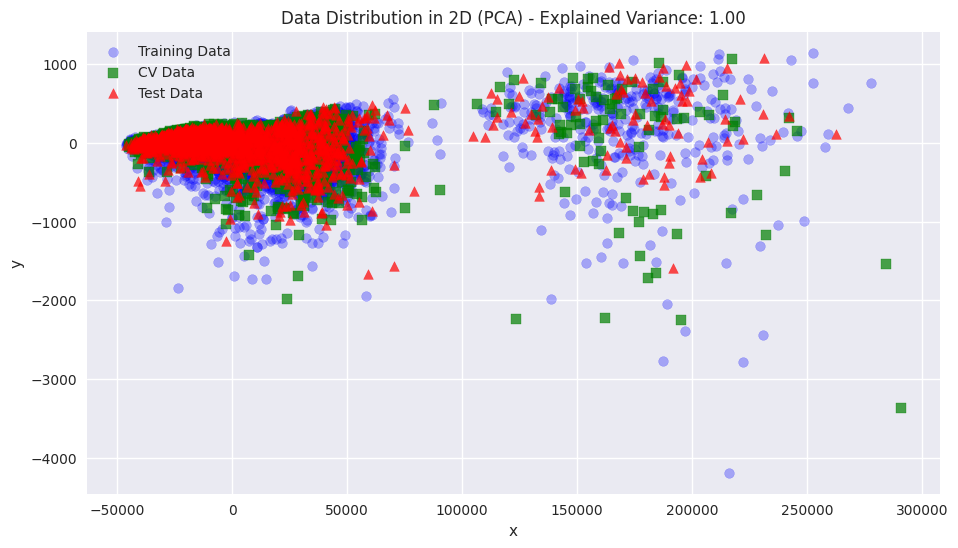

In [7]:
# 1. Compress 16 features down to 2 components
pca = PCA(n_components = 2)
X_train_pca = pca.fit_transform(X_train_full) # Fit on train
X_cv_pca = pca.transform(X_cv_full)       # Transform cv using train's rules
X_test_pca = pca.transform(X_test_full)       # Transform test using train's rules

# 2. Plot
plt.figure(figsize=(11, 6))

# Plot Training data (faded blue)
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
            alpha=0.3, label='Training Data', c='blue')

# Plot CV data (brown)
plt.scatter(X_cv_pca[:, 0], X_cv_pca[:, 1],
            alpha=0.7, label='CV Data', c='green', marker='s')

# Plot Test data (bright red)
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1],
            alpha=0.7, label='Test Data', c='red', marker='^')

plt.title(f'Data Distribution in 2D (PCA) - Explained Variance: {pca.explained_variance_ratio_.sum():.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## 3 Pipeline for Logistic Regression

### 3.1 No regularization

Iterative training loop from 1 until 10001. Extracting accuraccy of training and cv and plotting the differences.

In [8]:
# --- Iterative Training Loop ---
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2", 
        solver="lbfgs",
        max_iter=1,
        warm_start=True,
        random_state=42
    ))
])

train_scores = []
cv_scores = []
train_losses = []
cv_losses = []

# Define iteration points: start from very small values, then increase
# Very early iterations: 1, 5, then 10-90
# Early iterations with smaller steps, then larger steps
very_early_iterations = list(range(1, 10, 1))  # Start from iteration 1
early_iterations = list(range(10, 100, 10))  # 10, 20, 30, ..., 90
mid_iterations = list(range(100, 1000, 100))  # 100, 200, ..., 900
late_iterations = list(range(1000, 10001, 1000))  # 1000, 2000, ..., 10000

iter_values = very_early_iterations + early_iterations + mid_iterations + late_iterations

print(f"Training from iteration {iter_values[0]} to {iter_values[-1]}")
print(f"Total checkpoints: {len(iter_values)}")

for i in iter_values:
    model.set_params(logreg__max_iter=i)
    model.fit(X_train_full, y_train_full)
    
    # Calculate scores...
    y_train_pred = model.predict(X_train_full)
    y_cv_pred = model.predict(X_cv_full)
    train_acc = accuracy_score(y_train_full, y_train_pred) * 100
    cv_acc = accuracy_score(y_cv_full, y_cv_pred) * 100
    train_scores.append(train_acc)
    cv_scores.append(cv_acc)

    # Calculate losses...
    train_loss = log_loss(y_train_full, model.predict_proba(X_train_full))
    cv_loss = log_loss(y_cv_full, model.predict_proba(X_cv_full))
    train_losses.append(train_loss)
    cv_losses.append(cv_loss)

    # Print progress for very early, early, and milestone iterations
    if i <= 10 or (i <= 100 and i % 10 == 0) or i >= 9000 or i % 1000 == 0:
        print(f'Iteration {i:5d}: Train Acc={train_acc:.2f}%, CV Acc={cv_acc:.2f}%, Train Loss={train_loss:.4f}, CV Loss={cv_loss:.4f}')   

Training from iteration 1 to 10000
Total checkpoints: 37
Iteration     1: Train Acc=66.86%, CV Acc=67.50%, Train Loss=1.1531, CV Loss=1.1456
Iteration     2: Train Acc=85.79%, CV Acc=85.35%, Train Loss=0.5750, CV Loss=0.5661
Iteration     3: Train Acc=90.26%, CV Acc=90.16%, Train Loss=0.4232, CV Loss=0.4122
Iteration     4: Train Acc=91.94%, CV Acc=92.21%, Train Loss=0.2508, CV Loss=0.2331
Iteration     5: Train Acc=92.26%, CV Acc=92.34%, Train Loss=0.2305, CV Loss=0.2217
Iteration     6: Train Acc=91.92%, CV Acc=92.61%, Train Loss=0.2217, CV Loss=0.2080
Iteration     7: Train Acc=92.54%, CV Acc=92.79%, Train Loss=0.2168, CV Loss=0.2052
Iteration     8: Train Acc=92.52%, CV Acc=92.83%, Train Loss=0.2153, CV Loss=0.2029
Iteration     9: Train Acc=92.61%, CV Acc=92.83%, Train Loss=0.2142, CV Loss=0.2027
Iteration    10: Train Acc=92.62%, CV Acc=92.83%, Train Loss=0.2135, CV Loss=0.2028
Iteration    20: Train Acc=92.62%, CV Acc=92.88%, Train Loss=0.2119, CV Loss=0.2011
Iteration    30: Tr

### 3.1.1 Evaluation

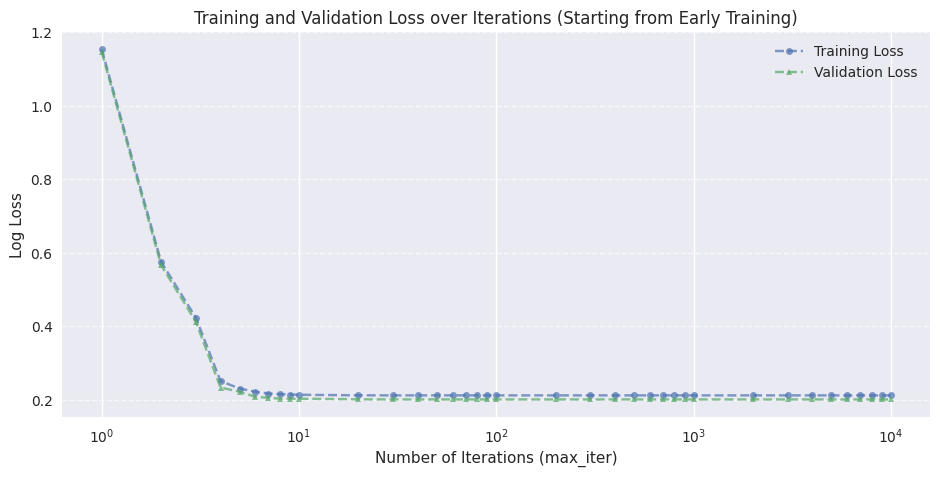

In [9]:
# Plot training and validation loss over iterations
plt.figure(figsize=(11.2, 5))
plt.plot(iter_values, train_losses, linestyle='dashed', label='Training Loss', marker='o', alpha=0.7, markersize=5)
plt.plot(iter_values, cv_losses, linestyle='dashed', label='Validation Loss', marker='^', alpha=0.7, markersize=5)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Training and Validation Loss over Iterations (Starting from Early Training)')
plt.ylabel('Log Loss')
plt.xlabel('Number of Iterations (max_iter)')
plt.legend()
plt.xscale('log')  # Use log scale for better visualization of early iterations
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

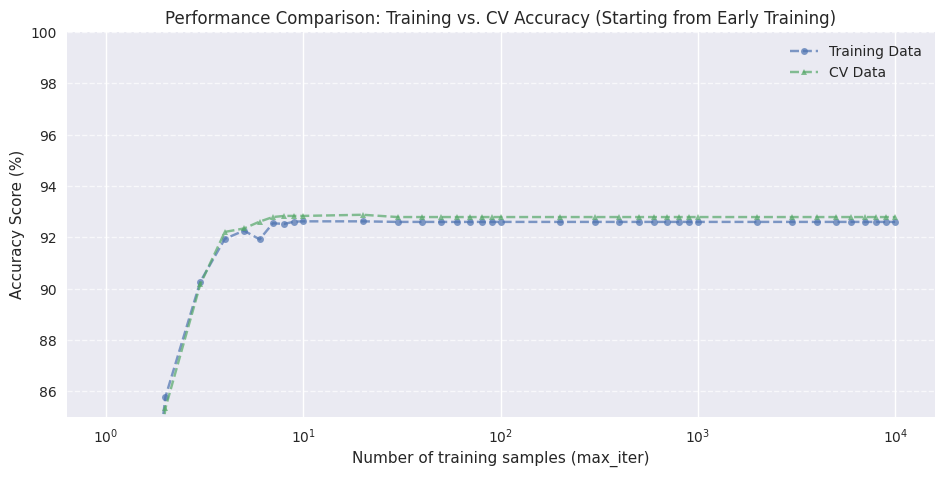

In [10]:
# Plotting code follows...
plt.figure(figsize=(11.2, 5))
plt.plot(iter_values, train_scores, linestyle='dashed', label='Training Data', marker='o', alpha=0.7, markersize=5)
plt.plot(iter_values, cv_scores, linestyle='dashed', label='CV Data', marker='^', alpha=0.7, markersize=5)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Performance Comparison: Training vs. CV Accuracy (Starting from Early Training)')
plt.ylabel('Accuracy Score (%)')
plt.xlabel('Number of training samples (max_iter)')
plt.ylim(85, 100)
plt.xscale('log')  # Use log scale for better visualization of early iterations
plt.legend()
plt.show

In [11]:
# predict and evaluate on training data
y_train_pred = model.predict(X_train_full)
acc_train = accuracy_score(y_train_full, y_train_pred)
error_rate_train = 1 - acc_train

# predict and evaluate on cv data, find error
y_cv_pred = model.predict(X_cv_full)
acc_cv = accuracy_score(y_cv_full, y_cv_pred)
error_rate_cv = 1 - acc_cv

# predict and evaluate on test data, find error
y_test_pred = model.predict(X_test_full)
acc_test = accuracy_score(y_test_full, y_test_pred)
error_rate_test = 1 - acc_test

cost_train = log_loss(y_train_full, model.predict_proba(X_train_full))
cost_cv = log_loss(y_cv_full, model.predict_proba(X_cv_full))
cost_test = log_loss(y_test_full, model.predict_proba(X_test_full))
# Print Comparison
print(f"Training Accuracy, error rate and cost: {acc_train*100:.2f} {error_rate_train*100:.2f} {cost_train*100:.2f}%")
print(f"CV Accuracy, error rate and cost: {acc_cv*100:.4f} {error_rate_cv*100:.2f} {cost_cv*100:.2f}%")
print(f"Test Accuracy, error rate and cost: {acc_test*100:.4f} {error_rate_test*100:.2f} {cost_test*100:.2f}%")

Training Accuracy, error rate and cost: 92.60 7.40 21.18%
CV Accuracy, error rate and cost: 92.7872 7.21 20.08%
Test Accuracy, error rate and cost: 91.5405 8.46 22.19%


_Note: Reorder the labels to match the paper comparison [[3]](../README.md#3). The order is `'SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON'`._

**Detailed Report (Precision, Recall, F1-score)**

 * Precision - Out of all the times the model predicted a class, how many were correct?
 * Recal - Out of all the actual instances of a class, how many did the model correctly find?
 * F1-Score - The harmonic mean of Precision and Recall.

***Confusion Matrix (Visualizing where the error occurs)***


--- Confusion Matrix (Raw Counts) ---
[[315   1   0   0   0  11   7]
 [  4 188   0  13   2  12   0]
 [  0   0  86   0   0   0   0]
 [  2   6   0 253   4   4   0]
 [  0   1   0   1 306   5   5]
 [  4   0   0   1  11 382  37]
 [  9   0   0   0   0  50 526]]


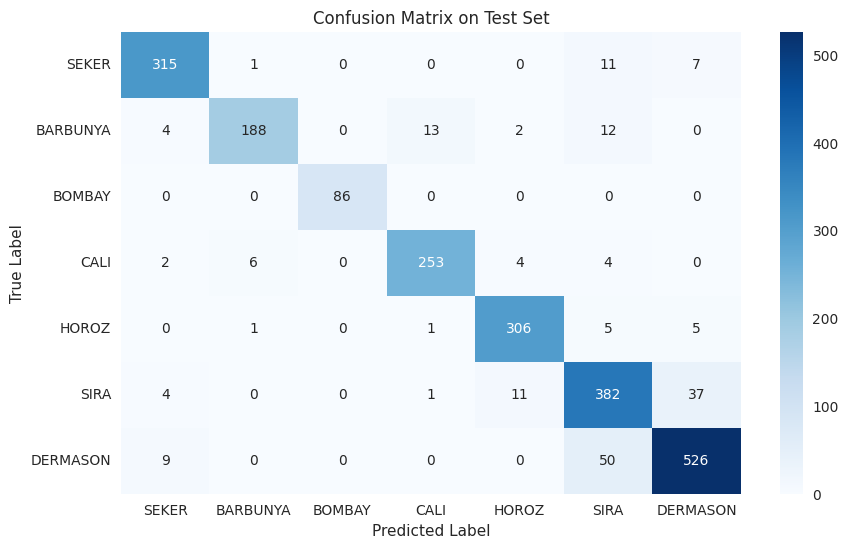

In [12]:
cm = confusion_matrix(y_test_full, y_test_pred, labels=label_encoder_full.transform(labels_desired_order))
print("\n--- Confusion Matrix (Raw Counts) ---")
print(cm)

cm_df = pd.DataFrame(
    cm,
    index=labels_desired_order, 
    columns=labels_desired_order
)

plt.figure(figsize=(10, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_desired_order,
            yticklabels=labels_desired_order,)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 3.2 With regularization

Since the model already achieved a good fit, we can plot a Validation Curve to see how varying the regularization strength (C) affects the model's performance and generalization ability.

In [19]:
# C_values were set from 0.001 (strongest penalty) to 1000.0 (weakest penalty)
C_values = np.logspace(-3, 6, 7)

train_scores_reg = []
cv_scores_reg = []

scores_reg_result = {}

for C in C_values:
    model_reg = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            C=C, 
            penalty="l2",
            solver="lbfgs",
            max_iter=5000,
            warm_start=True,
            random_state=42
        ))
    ])
    
    # Train and evaluate the model for the current C
    model_reg.fit(X_train_full, y_train_full)
    # ... record scores ...
    y_train_pred = model_reg.predict(X_train_full)
    y_cv_pred = model_reg.predict(X_cv_full)
    train_scores_reg.append(accuracy_score(y_train_full, y_train_pred) * 100)
    cv_scores_reg.append(accuracy_score(y_cv_full, y_cv_pred) * 100)

    ts = accuracy_score(y_train_full, y_train_pred) * 100
    cv = accuracy_score(y_cv_full, y_cv_pred) * 100

    scores_reg_result[C] = {
        "train_scores": ts,
        "cv_scores": cv
    }

In [21]:
print(C_values)
print(train_scores_reg)
print(cv_scores_reg)
best_C = max(scores_reg_result.keys(), key=lambda c: scores_reg_result[c]['cv_scores'])
print(f"Best C: {best_C}")
best_result = scores_reg_result[best_C]
print(best_result)


[1.00000000e-03 3.16227766e-02 1.00000000e+00 3.16227766e+01
 1.00000000e+03 3.16227766e+04 1.00000000e+06]
[89.56025880030705, 92.2469569031692, 92.59787257374713, 92.67463537668604, 92.83912709726944, 92.850093211975, 92.80622875315275]
[89.53695458593054, 92.47551202137133, 92.78717720391808, 92.60908281389136, 92.56455921638468, 92.56455921638468, 92.52003561887801]
Best C: 1.0
{'train_scores': 92.59787257374713, 'cv_scores': 92.78717720391808}


<function matplotlib.pyplot.show(close=None, block=None)>

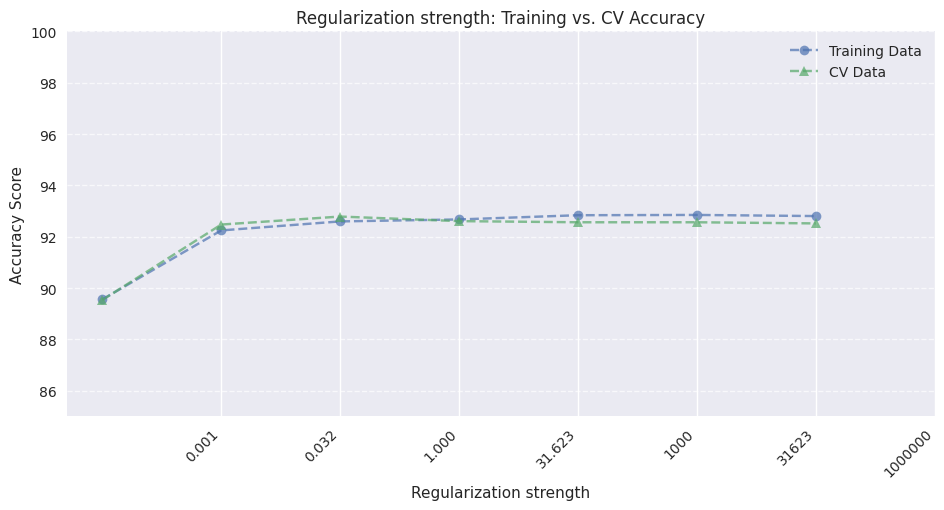

In [22]:
# 1. Transform the numerical array into a list of formatted strings (labels)
labels = [f'{c:.3f}' if c < 100 else f'{c:.0f}' for c in C_values]
val = np.array([1, 2, 3, 4, 5, 6, 7])
# Plotting code follows...
plt.figure(figsize=(11.2, 5))
plt.plot(train_scores_reg, linestyle='dashed', label='Training Data', marker='o', alpha=0.7)
plt.plot(cv_scores_reg, linestyle='dashed', label='CV Data', marker='^', alpha=0.7)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(val, labels=labels, rotation=45, ha='right')
plt.title('Regularization strength: Training vs. CV Accuracy')
plt.legend()
plt.ylabel('Accuracy Score')
plt.xlabel('Regularization strength')
plt.ylim(85, 100)
plt.show

In [23]:
# --- Iterative Training Loop (Starting from zero) ---
model_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        C=best_C, 
        penalty="l2",
        solver="lbfgs",
        max_iter=1,
        warm_start=True,
        random_state=42
    ))
])

train_scores_reg = []
cv_scores_reg = []
train_losses_reg = []
cv_losses_reg = []
iter_values = []

# Define iteration points: start from very small values, then increase
# Very early iterations: 1, 5, then 10-90
# Early iterations with smaller steps, then larger steps
very_early_iterations = list(range(1, 10, 1))  # Start from iteration 1
early_iterations = list(range(10, 100, 10))  # 10, 20, 30, ..., 90
mid_iterations = list(range(100, 1000, 100))  # 100, 200, ..., 900
late_iterations = list(range(1000, 10001, 1000))  # 1000, 2000, ..., 10000

iter_values = very_early_iterations + early_iterations + mid_iterations + late_iterations

print(f"Training from iteration {iter_values[0]} to {iter_values[-1]}")
print(f"Total checkpoints: {len(iter_values)}")

for i in iter_values:
    model_reg.set_params(logreg__max_iter=i)
    model_reg.fit(X_train_full, y_train_full)
    
    # Calculate scores...
    y_train_pred_reg = model_reg.predict(X_train_full)
    y_cv_pred_reg = model_reg.predict(X_cv_full)
    train_acc_reg = accuracy_score(y_train_full, y_train_pred_reg) * 100
    cv_acc_reg = accuracy_score(y_cv_full, y_cv_pred_reg) * 100
    train_scores_reg.append(train_acc_reg)
    cv_scores_reg.append(cv_acc_reg)
    
    # Calculate losses...
    train_loss_reg = log_loss(y_train_full, model_reg.predict_proba(X_train_full))
    cv_loss_reg = log_loss(y_cv_full, model_reg.predict_proba(X_cv_full))
    train_losses_reg.append(train_loss_reg)
    cv_losses_reg.append(cv_loss_reg)
    
    # Print progress for very early, early, and milestone iterations
    if i <= 10 or (i <= 100 and i % 10 == 0) or i >= 9000 or i % 1000 == 0:
        print(f'Iteration {i:5d}: Train Acc={train_acc_reg:.2f}%, CV Acc={cv_acc_reg:.2f}%, Train Loss={train_loss_reg:.4f}, CV Loss={cv_loss_reg:.4f}')

Training from iteration 1 to 10000
Total checkpoints: 37
Iteration     1: Train Acc=66.86%, CV Acc=67.50%, Train Loss=1.1531, CV Loss=1.1456
Iteration     2: Train Acc=85.79%, CV Acc=85.35%, Train Loss=0.5750, CV Loss=0.5661
Iteration     3: Train Acc=90.26%, CV Acc=90.16%, Train Loss=0.4232, CV Loss=0.4122
Iteration     4: Train Acc=91.94%, CV Acc=92.21%, Train Loss=0.2508, CV Loss=0.2331
Iteration     5: Train Acc=92.26%, CV Acc=92.34%, Train Loss=0.2305, CV Loss=0.2217
Iteration     6: Train Acc=91.92%, CV Acc=92.61%, Train Loss=0.2217, CV Loss=0.2080
Iteration     7: Train Acc=92.54%, CV Acc=92.79%, Train Loss=0.2168, CV Loss=0.2052
Iteration     8: Train Acc=92.52%, CV Acc=92.83%, Train Loss=0.2153, CV Loss=0.2029
Iteration     9: Train Acc=92.61%, CV Acc=92.83%, Train Loss=0.2142, CV Loss=0.2027
Iteration    10: Train Acc=92.62%, CV Acc=92.83%, Train Loss=0.2135, CV Loss=0.2028
Iteration    20: Train Acc=92.62%, CV Acc=92.88%, Train Loss=0.2119, CV Loss=0.2011
Iteration    30: Tr

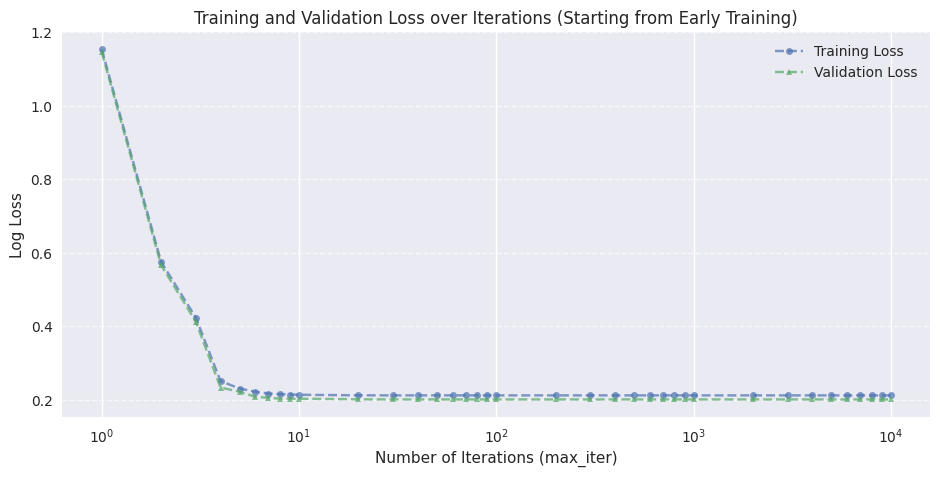

In [24]:
# Plot training and validation loss over iterations
plt.figure(figsize=(11.2, 5))
plt.plot(iter_values, train_losses_reg, linestyle='dashed', label='Training Loss', marker='o', alpha=0.7, markersize=5)
plt.plot(iter_values, cv_losses_reg, linestyle='dashed', label='Validation Loss', marker='^', alpha=0.7, markersize=5)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Training and Validation Loss over Iterations (Starting from Early Training)')
plt.ylabel('Log Loss')
plt.xlabel('Number of Iterations (max_iter)')
plt.legend()
plt.xscale('log')  # Use log scale for better visualization of early iterations
plt.show()


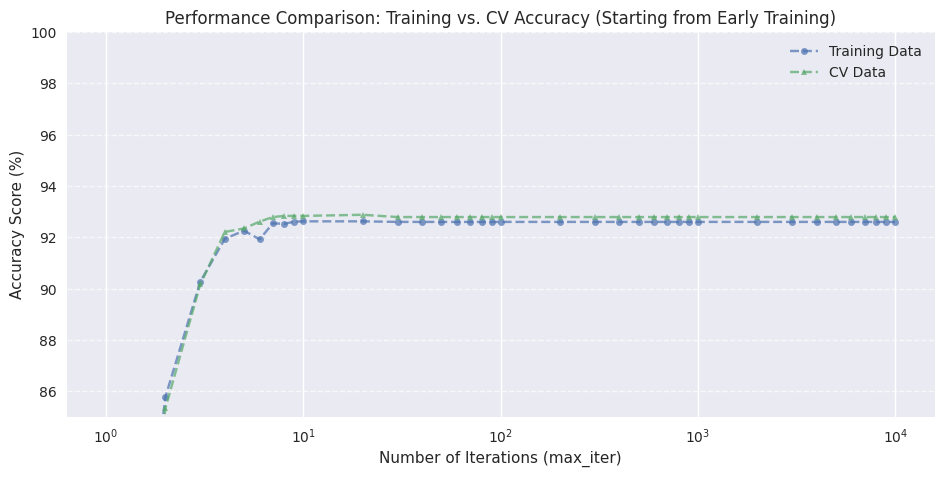

In [25]:
# Plot training and validation accuracy over iterations
plt.figure(figsize=(11.2, 5))
plt.plot(iter_values, train_scores_reg, linestyle='dashed', label='Training Data', marker='o', alpha=0.7, markersize=5)
plt.plot(iter_values, cv_scores_reg, linestyle='dashed', label='CV Data', marker='^', alpha=0.7, markersize=5)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Performance Comparison: Training vs. CV Accuracy (Starting from Early Training)')
plt.ylabel('Accuracy Score (%)')
plt.xlabel('Number of Iterations (max_iter)')
plt.ylim(85, 100)
plt.xscale('log')  # Use log scale for better visualization of early iterations
plt.legend()
plt.show()

In [26]:
# predict and evaluate on training data
y_train_pred_reg = model_reg.predict(X_train_full)
acc_train_reg = accuracy_score(y_train_full, y_train_pred_reg)
error_rate_train_reg = 1 - acc_train_reg

# predict and evaluate on cv data, find error
y_cv_pred_reg = model_reg.predict(X_cv_full)
acc_cv_reg = accuracy_score(y_cv_full, y_cv_pred_reg)
error_rate_cv_reg = 1 - acc_cv_reg

# predict and evaluate on test data, find error
y_test_pred_reg = model_reg.predict(X_test_full)
acc_test_reg = accuracy_score(y_test_full, y_test_pred_reg)
error_rate_test_reg = 1 - acc_test_reg

cost_train_reg = log_loss(y_train_full, model_reg.predict_proba(X_train_full))
cost_cv_reg = log_loss(y_cv_full, model_reg.predict_proba(X_cv_full))
cost_test_reg = log_loss(y_test_full, model_reg.predict_proba(X_test_full))
# Print Comparison
print(f"Training Accuracy, error rate and cost: {acc_train_reg*100:.2f} {error_rate_train_reg*100:.2f} {cost_train_reg*100:.2f}%")
print(f"CV Accuracy, error rate and cost: {acc_cv_reg*100:.4f} {error_rate_cv_reg*100:.2f} {cost_cv_reg*100:.2f}%")
print(f"Test Accuracy, error rate and cost: {acc_test_reg*100:.4f} {error_rate_test_reg*100:.2f} {cost_test_reg*100:.2f}%")

Training Accuracy, error rate and cost: 92.60 7.40 21.18%
CV Accuracy, error rate and cost: 92.7872 7.21 20.08%
Test Accuracy, error rate and cost: 91.5405 8.46 22.19%


***Confusion Matrix (Visualizing where the error occurs)***


--- Confusion Matrix (Raw Counts) ---
[[315   1   0   0   0  11   7]
 [  4 188   0  13   2  12   0]
 [  0   0  86   0   0   0   0]
 [  2   6   0 253   4   4   0]
 [  0   1   0   1 306   5   5]
 [  4   0   0   1  11 382  37]
 [  9   0   0   0   0  50 526]]


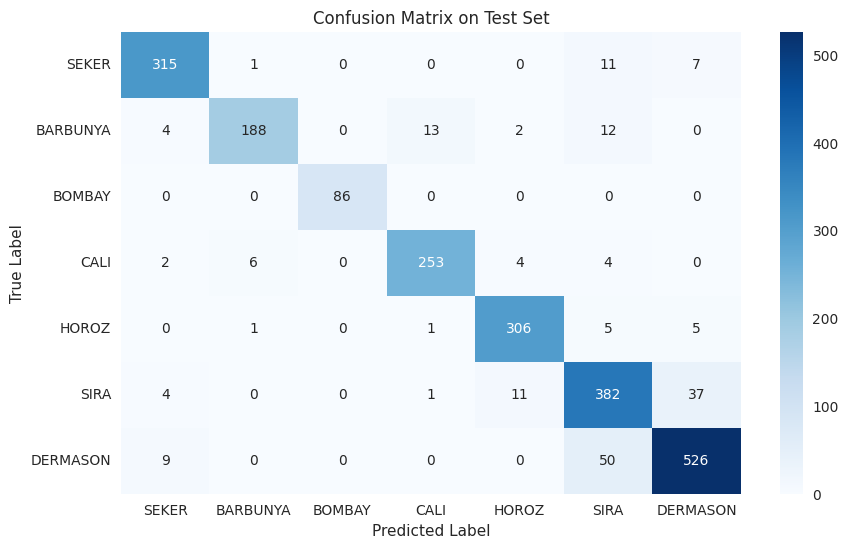

In [27]:
cm_reg = confusion_matrix(y_test_full, y_test_pred_reg, labels=label_encoder_full.transform(labels_desired_order))
print("\n--- Confusion Matrix (Raw Counts) ---")
print(cm_reg)

cm_reg_df = pd.DataFrame(
    cm_reg,
    index=labels_desired_order, 
    columns=labels_desired_order
)

plt.figure(figsize=(10, 6))
sns.heatmap(cm_reg_df, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_desired_order,
            yticklabels=labels_desired_order,)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [28]:
print("\n--- Classification Test Report ---")
# This provides metrics for each of your 7 classes
report = classification_report(y_test_full, y_test_pred_reg, labels=label_encoder_full.transform(labels_desired_order), output_dict=True)
ut.classification_report_to_file(report, "lr_scikit")
print(report)

print(classification_report(y_test_full, y_test_pred_reg, labels=label_encoder_full.transform(labels_desired_order)))


--- Classification Test Report ---
Metrics saved to 'classification_report/lr_scikit.json'
{'5': {'precision': 0.9431137724550899, 'recall': 0.9431137724550899, 'f1-score': 0.9431137724550899, 'support': 334.0}, '0': {'precision': 0.9591836734693877, 'recall': 0.8584474885844748, 'f1-score': 0.9060240963855422, 'support': 219.0}, '1': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 86.0}, '2': {'precision': 0.9440298507462687, 'recall': 0.9405204460966543, 'f1-score': 0.9422718808193669, 'support': 269.0}, '4': {'precision': 0.9473684210526315, 'recall': 0.9622641509433962, 'f1-score': 0.9547581903276131, 'support': 318.0}, '6': {'precision': 0.8232758620689655, 'recall': 0.8781609195402299, 'f1-score': 0.8498331479421579, 'support': 435.0}, '3': {'precision': 0.9147826086956522, 'recall': 0.8991452991452992, 'f1-score': 0.906896551724138, 'support': 585.0}, 'accuracy': 0.9154051647373108, 'macro avg': {'precision': 0.9331077412125708, 'recall': 0.9259502966807348, 'f1-s